C:\Users\Pooja Kadam\AppData\Local\Temp\ipykernel_28364\3384204722.py:26: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(complex_signal, fs=1000.0, nperseg=16, noverlap=8)


✅ Train spectrograms saved! Shape: (24000, 32, 32, 3)


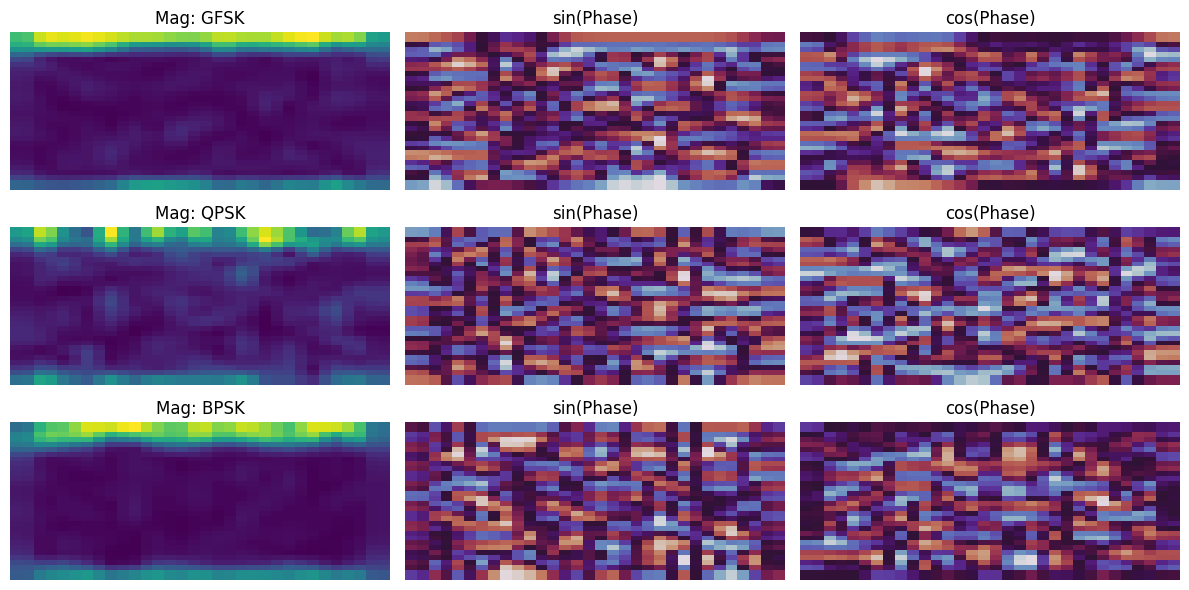

In [27]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from scipy.signal import stft
from skimage.transform import resize

# === Load Training Data ===
with open("train_samples.pkl", "rb") as f:
    train_data = pickle.load(f)

X_train = train_data["signals"]  # Shape: (N, 2, 128)
y_train = np.array(train_data["labels"])

# === Output Directory ===
output_dir = "rml_train_spectrograms_3ch_stft"
os.makedirs(output_dir, exist_ok=True)

# === Create 3-Channel Spectrograms ===
spectrogram_list = []
for iq_sample in X_train:
    I, Q = iq_sample[0, :], iq_sample[1, :]
    complex_signal = I + 1j * Q

    # Compute STFT
    f, t, Zxx = stft(complex_signal, fs=1000.0, nperseg=16, noverlap=8)

    # Magnitude and Phase
    mag = np.abs(Zxx)
    mag = mag / np.max(mag) if np.max(mag) > 0 else mag
    phase = np.angle(Zxx)
    sin_phase = (np.sin(phase) + 1) / 2
    cos_phase = (np.cos(phase) + 1) / 2

    # Resize to (32, 32)
    mag = resize(mag, (32, 32), anti_aliasing=True)
    sin_phase = resize(sin_phase, (32, 32), anti_aliasing=True)
    cos_phase = resize(cos_phase, (32, 32), anti_aliasing=True)

    # Stack into RGB-like image
    spec_img = np.stack([mag, sin_phase, cos_phase], axis=-1)
    spectrogram_list.append(spec_img)

# === Save Spectrograms and Labels ===
spectrogram_array = np.array(spectrogram_list, dtype=np.float16)
np.save(os.path.join(output_dir, "train_spectrograms_3ch_stft.npy"), spectrogram_array)
np.save(os.path.join(output_dir, "train_labels_3ch_stft.npy"), y_train)

print(f"✅ Train spectrograms saved! Shape: {spectrogram_array.shape}")

# === Optional: Visualize Some Samples ===
plt.figure(figsize=(12, 6))
for i in range(3):
    idx = np.random.randint(0, len(spectrogram_array))
    plt.subplot(3, 3, 3 * i + 1)
    plt.imshow(spectrogram_array[idx, :, :, 0], cmap='viridis', aspect='auto')
    plt.title(f"Mag: {y_train[idx]}")
    plt.axis('off')

    plt.subplot(3, 3, 3 * i + 2)
    plt.imshow(spectrogram_array[idx, :, :, 1], cmap='twilight', aspect='auto')
    plt.title("sin(Phase)")
    plt.axis('off')

    plt.subplot(3, 3, 3 * i + 3)
    plt.imshow(spectrogram_array[idx, :, :, 2], cmap='twilight', aspect='auto')
    plt.title("cos(Phase)")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# === Load Custom 3-channel Spectrogram Dataset ===
dataset_dir = "rml_train_spectrograms_3ch_stft"
spectrograms_3ch = np.load(os.path.join(dataset_dir, "train_spectrograms_3ch_stft.npy"))  # shape: (N, 32, 32, 3)
labels = np.load(os.path.join(dataset_dir, "train_labels_3ch_stft.npy"))

# === Use ONLY the magnitude channel (index 0) ===
#spectrograms = spectrograms_3ch[..., 0]  # shape: (N, 32, 32)
# Before: using only magnitude
# spectrograms = spectrograms_3ch[..., 0]
# spectrograms = spectrograms[..., np.newaxis]

# Now: use all 3 channels
spectrograms = spectrograms_3ch  # shape: (N, 32, 32, 3)

# === Normalize Spectrograms ===
spectrograms = spectrograms / np.max(spectrograms)

# === Encode Labels ===
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

# === Reshape for CNN ===
spectrograms = spectrograms[..., np.newaxis]  # shape: (N, 32, 32, 1)

# === Compute Class Weights (optional but good for imbalance) ===
class_weights = compute_class_weight('balanced', classes=np.unique(labels_encoded), y=labels_encoded)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

# === Learning Rate Scheduler ===
lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.3, patience=3, verbose=1, min_lr=1e-7)

# === Define CNN Model ===
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(labels_encoded)), activation='softmax')
])

# === Compile the Model ===
model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

# === Train on Entire Dataset ===
history = model.fit(
    spectrograms, labels_categorical,
    batch_size=32,
    epochs=100,
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler]
)

# === Save the Trained Model ===
model.save("cnn_modulation_classifier_RML_trained.h5")
print("Model trained on full dataset and saved successfully!")

# === (Optional) Save the Label Encoder for Decoding Later ===
import pickle
with open("label_encoder_RML.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.3115 - loss: 1.6083 - learning_rate: 5.0000e-04
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.4858 - loss: 1.0604 - learning_rate: 5.0000e-04
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5699 - loss: 0.8758 - learning_rate: 5.0000e-04
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5908 - loss: 0.7803 - learning_rate: 5.0000e-04
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6142 - loss: 0.7224 - learning_rate: 5.0000e-04
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6270 - loss: 0.6822 - learning_rate: 5.0000e-04
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6408 - loss: 0.6648 - learning_rate: 5.0000e-04
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6397 - loss: 0.6489 - learning_rate: 5.0000e-04
Epoch 9/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accurac

Model trained on full dataset and saved successfully!


C:\Users\Pooja Kadam\AppData\Local\Temp\ipykernel_16980\2668754199.py:18: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(complex_signal, fs=1000.0, nperseg=16, noverlap=8)


✅ Saved: test_samples_snr0_spectrograms.npy — shape: (1200, 32, 32, 3)


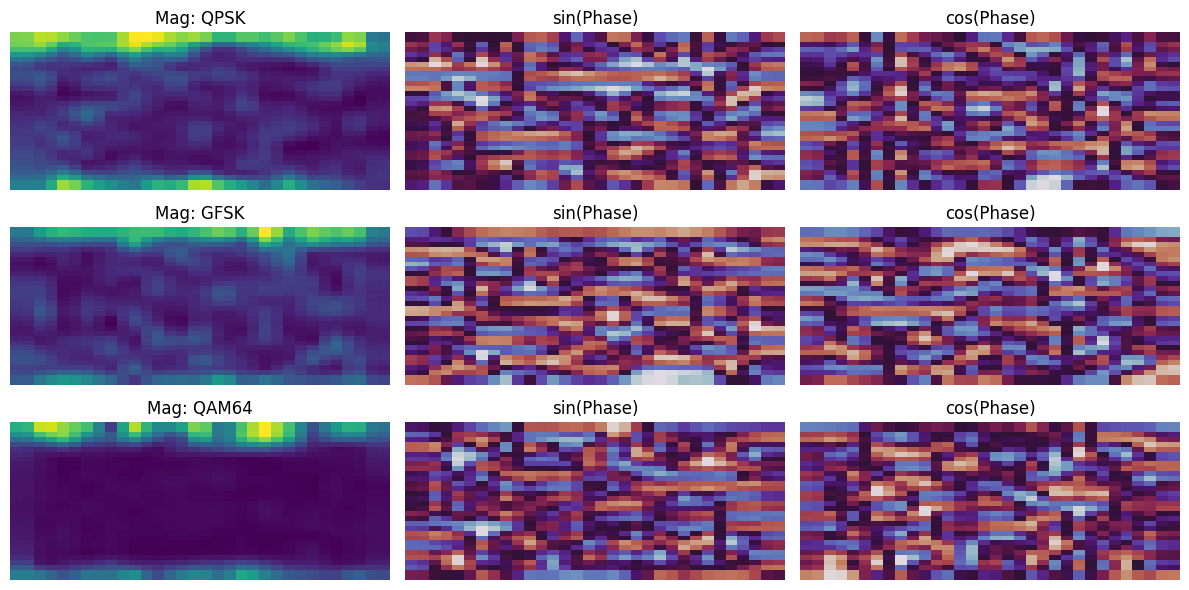

In [2]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from scipy.signal import stft
from skimage.transform import resize
from glob import glob

# === Input & Output Directories ===
test_files = sorted(glob("test_samples_snr0.pkl"))  # Automatically finds all test files
output_dir = "rml_test0_spectrograms_3ch_stft"
os.makedirs(output_dir, exist_ok=True)

# === STFT Spectrogram Function ===
def generate_3ch_spectrogram(iq_sample):
    I, Q = iq_sample[0, :], iq_sample[1, :]
    complex_signal = I + 1j * Q
    f, t, Zxx = stft(complex_signal, fs=1000.0, nperseg=16, noverlap=8)

    mag = np.abs(Zxx)
    mag = mag / np.max(mag) if np.max(mag) > 0 else mag

    phase = np.angle(Zxx)
    sin_phase = (np.sin(phase) + 1) / 2
    cos_phase = (np.cos(phase) + 1) / 2

    mag = resize(mag, (32, 32), anti_aliasing=True)
    sin_phase = resize(sin_phase, (32, 32), anti_aliasing=True)
    cos_phase = resize(cos_phase, (32, 32), anti_aliasing=True)

    return np.stack([mag, sin_phase, cos_phase], axis=-1)

# === Process Each Test File ===
for test_file in test_files:
    with open(test_file, "rb") as f:
        test_data = pickle.load(f)

    X_test = test_data["signals"]
    y_test = np.array(test_data["labels"])

    # Generate spectrograms
    spectrogram_list = [generate_3ch_spectrogram(iq) for iq in X_test]
    spectrogram_array = np.array(spectrogram_list, dtype=np.float16)

    # Save spectrograms and labels
    base_name = os.path.splitext(os.path.basename(test_file))[0]
    np.save(os.path.join(output_dir, f"{base_name}_spectrograms.npy"), spectrogram_array)
    np.save(os.path.join(output_dir, f"{base_name}_labels.npy"), y_test)

    print(f"✅ Saved: {base_name}_spectrograms.npy — shape: {spectrogram_array.shape}")

# === Optional: Visualize Some Samples from One SNR ===
sample_file = os.path.join(output_dir, "test_samples_snr0_spectrograms.npy")
sample_labels_file = os.path.join(output_dir, "test_samples_snr0_labels.npy")

if os.path.exists(sample_file):
    sample_spects = np.load(sample_file)
    sample_labels = np.load(sample_labels_file)

    plt.figure(figsize=(12, 6))
    for i in range(3):
        idx = np.random.randint(0, len(sample_spects))
        plt.subplot(3, 3, 3 * i + 1)
        plt.imshow(sample_spects[idx, :, :, 0], cmap='viridis', aspect='auto')
        plt.title(f"Mag: {sample_labels[idx]}")
        plt.axis('off')

        plt.subplot(3, 3, 3 * i + 2)
        plt.imshow(sample_spects[idx, :, :, 1], cmap='twilight', aspect='auto')
        plt.title("sin(Phase)")
        plt.axis('off')

        plt.subplot(3, 3, 3 * i + 3)
        plt.imshow(sample_spects[idx, :, :, 2], cmap='twilight', aspect='auto')
        plt.title("cos(Phase)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Sample Predictions:
Sample 0: BPSK (Confidence: 100.00%)
Sample 1: BPSK (Confidence: 100.00%)
Sample 2: BPSK (Confidence: 100.00%)
Sample 3: BPSK (Confidence: 100.00%)
Sample 4: BPSK (Confidence: 100.00%)


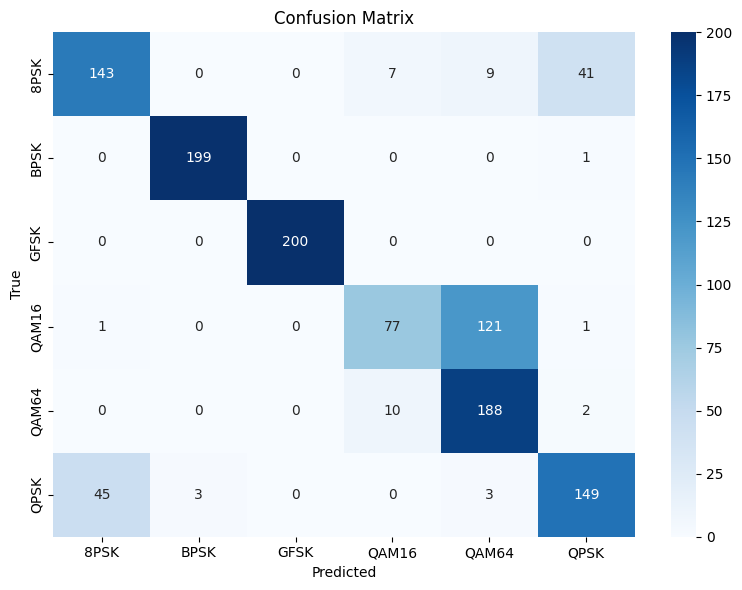


Classification Report:
               precision    recall  f1-score   support

        8PSK       0.76      0.71      0.74       200
        BPSK       0.99      0.99      0.99       200
        GFSK       1.00      1.00      1.00       200
       QAM16       0.82      0.39      0.52       200
       QAM64       0.59      0.94      0.72       200
        QPSK       0.77      0.74      0.76       200

    accuracy                           0.80      1200
   macro avg       0.82      0.80      0.79      1200
weighted avg       0.82      0.80      0.79      1200



In [4]:
import numpy as np
import os
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# === Load Trained Model & Label Encoder ===
model = load_model("cnn_modulation_classifier_RML_trained.h5")
with open("label_encoder_RML.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# === Load New Test Spectrograms ===
test_dir = "rml_test16_spectrograms_3ch_stft"  # or replace with your actual test dir
X_test = np.load(os.path.join(test_dir, "test_samples_snr16_spectrograms.npy"))  # shape: (N, 32, 32, 3)

# === If labels are available ===
has_labels = os.path.exists(os.path.join(test_dir, "test_samples_snr16_labels.npy"))
if has_labels:
    y_test_raw = np.load(os.path.join(test_dir, "test_samples_snr16_labels.npy"))
    y_test_encoded = label_encoder.transform(y_test_raw)
    y_test_categorical = to_categorical(y_test_encoded)

# === Use ONLY Magnitude Channel ===
#X_test = X_test[..., 0]  # Extract channel 0 (magnitude)
#X_test = X_test / np.max(X_test)
#X_test = X_test[..., np.newaxis]  # Shape becomes (N, 32, 32, 1)

X_test = X_test / np.max(X_test)  # Normalize all channels
# Already (N, 32, 32, 3), so no reshaping needed

# === Make Predictions ===
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
predicted_labels = label_encoder.inverse_transform(predicted_classes)

# === Show Sample Predictions with Confidence ===
print("\nSample Predictions:")
for i in range(5):
    print(f"Sample {i}: {predicted_labels[i]} (Confidence: {100 * np.max(predictions[i]):.2f}%)")

# === If Ground Truth Labels Exist: Evaluate ===
if has_labels:
    true_classes = np.argmax(y_test_categorical, axis=1)
    conf_matrix = confusion_matrix(true_classes, predicted_classes)

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Classification Report
    report = classification_report(true_classes, predicted_classes, target_names=label_encoder.classes_, zero_division=1)
    print("\nClassification Report:\n", report)


Epoch 1/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.3612 - loss: 1.4892 - val_accuracy: 0.5133 - val_loss: 1.0675 - learning_rate: 5.0000e-04
Epoch 2/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.5397 - loss: 0.9428 - val_accuracy: 0.6300 - val_loss: 0.6948 - learning_rate: 5.0000e-04
Epoch 3/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.6091 - loss: 0.7763 - val_accuracy: 0.6288 - val_loss: 0.6925 - learning_rate: 5.0000e-04
Epoch 4/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.6268 - loss: 0.7109 - val_accuracy: 0.4817 - val_loss: 1.1379 - learning_rate: 5.0000e-04
Epoch 5/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.6300 - loss: 0.6881 - val_accuracy: 0.6196 - val_loss: 0.6999 - learning_rate: 5.0000e-04
Epoch 6/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6374 - loss: 0.6640 - val_accuracy: 0.6671 - val_loss: 0.5574 - learning_rate: 5.0000e-04
Epoch 7/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/ste

Model trained with 90/10 split and saved successfully!


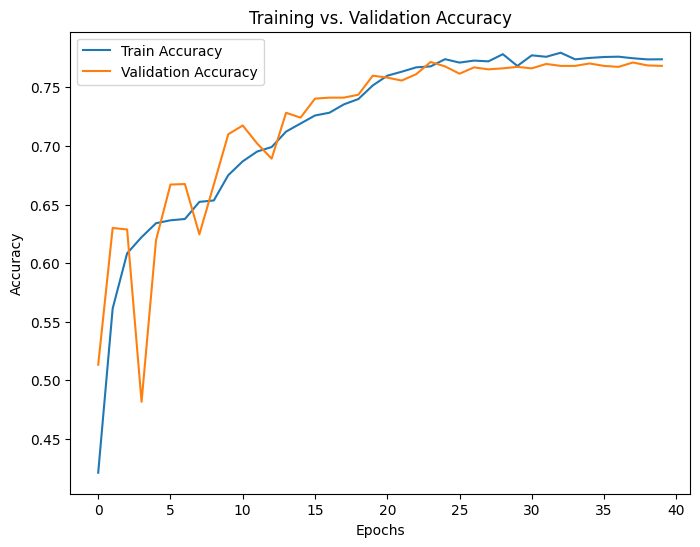

In [10]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import pickle

# === Load 3-channel Spectrogram Dataset ===
# === Load Custom 3-channel Spectrogram Dataset ===
dataset_dir = "rml_train_spectrograms_3ch_stft"
spectrograms_3ch = np.load(os.path.join(dataset_dir, "train_spectrograms_3ch_stft.npy"))  # shape: (N, 32, 32, 3)
labels = np.load(os.path.join(dataset_dir, "train_labels_3ch_stft.npy"))


# === Use ONLY the magnitude channel ===
spectrograms = spectrograms_3ch[..., 0]  # shape: (N, 32, 32)

# === Normalize and Reshape ===
spectrograms = spectrograms / np.max(spectrograms)
spectrograms = spectrograms[..., np.newaxis]  # shape: (N, 32, 32, 1)

# === Encode Labels ===
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

# === Split into Training and Validation (90/10) ===
X_train, X_val, y_train, y_val = train_test_split(
    spectrograms, labels_categorical, test_size=0.1, stratify=labels_categorical, random_state=42
)

# === Compute Class Weights ===
class_weights = compute_class_weight('balanced', classes=np.unique(labels_encoded), y=labels_encoded)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

# === Learning Rate Scheduler ===
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-7)
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# === CNN Model ===
model = Sequential([
    Input(shape=(32, 32, 1)),

    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(labels_encoded)), activation='softmax')
])

# === Compile Model ===
model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

# === Train Model ===
history = model.fit(
    X_train, y_train, batch_size=32,
    epochs=60, validation_data=(X_val, y_val),
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler, early_stopping]
)

# === Save Trained Model and Label Encoder ===
model.save("1_cnn_modulation_classifier_RML_trained.h5")
with open("1_label_encoder_RML.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Model trained with 90/10 split and saved successfully!")

# === Optional: Plot Training History ===
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs. Validation Accuracy")
plt.show()


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Sample Predictions:
Sample 0: BPSK (Confidence: 100.00%)
Sample 1: BPSK (Confidence: 100.00%)
Sample 2: BPSK (Confidence: 100.00%)
Sample 3: BPSK (Confidence: 99.28%)
Sample 4: BPSK (Confidence: 100.00%)


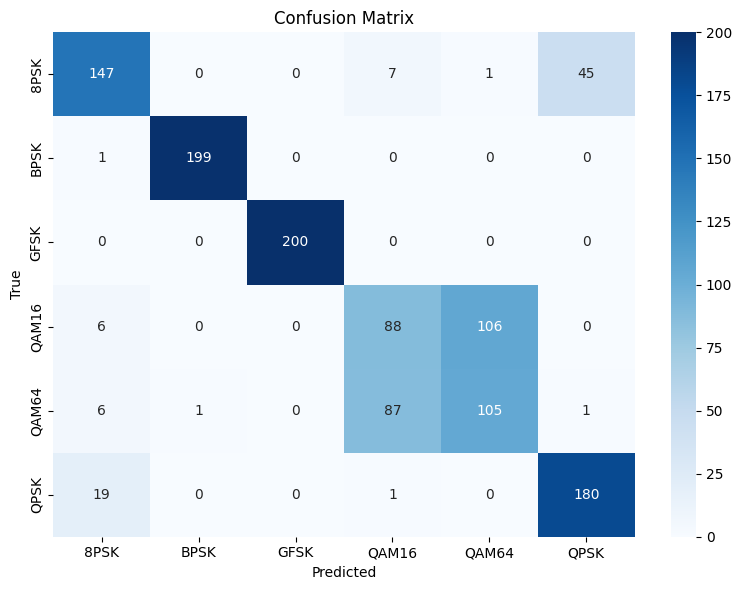


Classification Report:
               precision    recall  f1-score   support

        8PSK       0.82      0.73      0.78       200
        BPSK       0.99      0.99      0.99       200
        GFSK       1.00      1.00      1.00       200
       QAM16       0.48      0.44      0.46       200
       QAM64       0.50      0.53      0.51       200
        QPSK       0.80      0.90      0.85       200

    accuracy                           0.77      1200
   macro avg       0.76      0.77      0.76      1200
weighted avg       0.76      0.77      0.76      1200



In [21]:
import numpy as np
import os
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# === Load Trained Model & Label Encoder ===
model = load_model("1_cnn_modulation_classifier_RML_trained.h5")
with open("1_label_encoder_RML.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# === Load Test Spectrograms ===
test_dir = "rml_test16_spectrograms_3ch_stft"
X_test = np.load(os.path.join(test_dir, "test_samples_snr16_spectrograms.npy"))  # shape: (N, 32, 32, 3)

# === If labels are available ===
has_labels = os.path.exists(os.path.join(test_dir, "test_samples_snr16_labels.npy"))
if has_labels:
    y_test_raw = np.load(os.path.join(test_dir, "test_samples_snr16_labels.npy"))
    y_test_encoded = label_encoder.transform(y_test_raw)
    y_test_categorical = to_categorical(y_test_encoded)

# === Use ONLY Magnitude Channel ===
X_test = X_test[..., 0]  # Extract magnitude
X_test = X_test / np.max(X_test)
X_test = X_test[..., np.newaxis]  # Reshape to (N, 32, 32, 1)

# === Make Predictions ===
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
predicted_labels = label_encoder.inverse_transform(predicted_classes)

# === Show Sample Predictions with Confidence ===
print("\nSample Predictions:")
for i in range(5):
    print(f"Sample {i}: {predicted_labels[i]} (Confidence: {100 * np.max(predictions[i]):.2f}%)")

# === If Ground Truth Labels Exist: Evaluate ===
if has_labels:
    true_classes = np.argmax(y_test_categorical, axis=1)
    conf_matrix = confusion_matrix(true_classes, predicted_classes)

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Classification Report
    report = classification_report(true_classes, predicted_classes, target_names=label_encoder.classes_, zero_division=1)
    print("\nClassification Report:\n", report)
